# 07 — Experiments
**Author:** Elif Yegenoglu

This notebook documents key experiments/scratch models behind the final model, rebuilt on the final pipeline so
anyone can reproduce the **decisions** with Run All. 


## Contents
| Experiment | Question it answers |
|---|---|
| [E1 · Trivial baselines](#e1) | Is the problem learnable at all? (dummy vs logistic vs GB) |
| [E2 · Beliefs in vs out](#e2) | How much of the signal do the belief composites carry? |
| [E3 · Individual items vs composites](#e3) | Why two composites instead of the 10 raw TT4G35 items? |
| [E4 · Alternative Part 2 outcomes](#e4) | Is the student-facing definition driving the results? |
| [E5 · Fully weighted models](#e5) | Do survey weights (in fit and eval) change either model? |
| [E5b · Weighted 2×2 table + figure](#e5b) | The same result, rendered for the deck |
| [E6 · Hyperparameter tuning](#e6) | Would tuning beat the defaults? (slow — run last or skip) |


> **Shared setup** — copied verbatim from `02_model.ipynb` (same rule as 03/04: if the pipeline changes there, re-copy here).

In [1]:
# ============================================================
# CELL 0 — paths (portable: finds the repo by walking up from cwd)
# No editing needed on any machine. If it errors, open the repo
# folder itself in VS Code / Jupyter and restart the kernel.
# ============================================================
from pathlib import Path

def find_root(start=None, depth=6):
    p = start or Path.cwd()
    for _ in range(depth):
        if (p / "Data").exists() and (p / "Model").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        f"repo root not found walking up from {Path.cwd()} — "
        "in VS Code use File > Open Folder on summer26-teacher-ai-readiness, "
        "reopen this notebook, restart the kernel")

ROOT = find_root()
DATA_DIR = ROOT / "Data"                 # codebook + small CSVs
SPSS_DIR = DATA_DIR / "SPSS"             # raw TALIS .sav files (gitignored)
OUT_DIR  = DATA_DIR / "output"           # everything the notebooks produce (gitignored)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", ROOT)

repo root: c:\Users\elif_\Documents\summer26-teacher-ai-readiness


In [2]:
import matplotlib.pyplot as plt   # figures below need it (in 02 it arrives with the bake-off cell)

In [3]:
# ============================================================
# CELL 1 — load merged file, build ai_sample
# ============================================================
import re
import numpy as np
import pandas as pd

merged = pd.read_csv(DATA_DIR / "output" / "teacher_principal_named_columns.csv",
                     encoding="utf-8-sig", low_memory=False)
assert any(c.startswith("P_TC") for c in merged.columns), "no principal columns - wrong file?"

q36_col = next(c for c in merged.columns if c.startswith("TT4G36"))
q36_num = pd.to_numeric(merged[q36_col], errors="coerce")
ai_sample = merged[q36_num != 8].copy()
ai_sample[q36_col] = pd.to_numeric(ai_sample[q36_col], errors="coerce").replace(9, np.nan)
print("administered the AI module:", len(ai_sample))

administered the AI module: 92894


In [4]:
# ============================================================
# CELL 2 — teacher features (RQ1) + prep_general + belief composites
# Definitions = official TALIS 2024 codebook labels (abbreviated)
# ============================================================
cb = pd.read_csv(DATA_DIR / "talis2024_teacher_codebook.csv")

def tcol(v):
    """short code -> actual teacher column name in merged/ai_sample"""
    return next(c for c in ai_sample.columns if c.startswith(v + " ") or c == v)

# --- AI-belief COMPOSITES (mean of items; code 5 "I don't know" -> missing) ---
# Q35 scale: 1=Strongly disagree ... 4=Strongly agree, 5=I don't know (NOT on scale)
def belief_mean(items):
    B = ai_sample[[tcol(v) for v in items]].apply(pd.to_numeric, errors='coerce')
    B = B.replace(5, 2.5)                       # ← THIS LINE: "don't know" (5) -> neutral 2.5
    B = B.where(B.isin([1, 2, 2.5, 3, 4]))      # ← note 2.5 added to valid values
    return B.mean(axis=1).where(B.notna().sum(axis=1) >= 1)
ai_sample['ai_benefit_mean'] = belief_mean([f'TT4G35{c}' for c in 'ABCDE'])  # benefits
ai_sample['ai_risk_mean']    = belief_mean([f'TT4G35{c}' for c in 'FGHIJ'])  # risks/concerns

# --- general pedagogical preparation composite ---
# Q7a-e,g: prepared for content / subject pedagogy / general pedagogy /
# classroom practice / multicultural settings / student development
prep_codes = ['TT4G07A', 'TT4G07B', 'TT4G07C', 'TT4G07D', 'TT4G07E', 'TT4G07G']
P = ai_sample[[tcol(v) for v in prep_codes]].apply(pd.to_numeric, errors='coerce')
P = P.where(~P.isin([6, 8, 9]))
ai_sample['prep_general'] = P.mean(axis=1).where(P.notna().sum(axis=1) >= 4)

feature_cols = (
    # --- AI / digital core ---
    ['TT4G21G',   # Q21g: professional learning included "using AI for teaching and learning" (yes/no)
     'TT4G07F',   # Q7f: felt prepared for "use of digital resources and tools" (initial education)
     'TT4G27M']   # Q27m: self-efficacy — support learning through digital resources and tools

    # --- AI beliefs: two COMPOSITE scores (replaces the 10 Q35 items) ---
    + ['ai_benefit_mean',  # mean of Q35A-E; higher = agrees AI is beneficial
       'ai_risk_mean']     # mean of Q35F-J; higher = agrees AI is risky/concerning

    # --- derived: general pedagogical preparation ---
    + ['prep_general']

    # --- professional environment (TALIS derived scales) ---
    + ['T4COLES',   # Professional collaboration in lessons among teachers
       'T4TLEAD',   # Teacher leadership
       'T4VALP']    # Perceptions of value and policy influence
                    # NOTE: T4SELF (overall self-efficacy) dropped — overlaps with
                    # TT4G27M (digital self-efficacy), the AI-relevant facet we keep

    # --- wellbeing / stress (derived scales) ---
    + ['T4JOBSAT',  # Job satisfaction, overall
       'T4WLOADT',  # Workload stress
       'T4STBEH',   # Student behaviour stress
       'T4CHFAT']   # Change fatigue

    # --- workload ---
    + ['TT4G15']    # Q15: hours teaching at this school, most recent full week

    # --- demographics / employment (grouped) ---
    + ['T4TAGEGR',  # Teacher age (grouped)
       'T4TEMPWH',  # Employment status by working hours (grouped; CATEGORICAL)
       'T4TNSCH']   # Number of schools the teacher works at

    # --- structure ---
    + ['CNTRY']     # Country alpha code (CATEGORICAL, fixed effect)
)

withlabels = {
    'TT4G21G':         'Received AI Training',
    'ai_benefit_mean': 'AI-benefit beliefs',
    'ai_risk_mean':    'AI-risk beliefs',
    'CNTRY':           'Country',
    'TT4G27M':         'Digital self-efficacy',
    'TT4G07F':         'Digital preparedness',
    'prep_general':    'General preparation',
    'T4TAGEGR':        'Age group',
    'T4COLES':         'Professional collaboration',
    'T4TLEAD':         'Teacher leadership',
    'T4VALP':          'Perceived value & influence',
    'T4JOBSAT':        'Job satisfaction',
    'T4WLOADT':        'Workload stress',
    'T4STBEH':         'Student-behaviour stress',
    'T4CHFAT':         'Change fatigue',
    'TT4G15':          'Teaching hours',
    'T4TEMPWH':        'Employment status',
    'T4TNSCH':         'Number of schools',
}

assert len(feature_cols) == len(set(feature_cols))
print("teacher features:", len(feature_cols))   # 18

teacher features: 18


In [5]:
# ============================================================
# CELL 3 — assembly: ONE fixed complete-case sample + accounting
# ============================================================
def col_for(v):
    if v in ai_sample.columns:          # prep_general, composites
        return v
    return tcol(v)

all_short = feature_cols #+ school_block           # teacher features only (school block is for subset analysis)
D = ai_sample[[col_for(v) for v in all_short]].copy()
D.columns = all_short

# per-variable missing codes from the codebook (raw teacher vars only)
cb_codes = {}
for _, row in cb[cb.variable_name.isin(feature_cols)].iterrows():
    cb_codes[row.variable_name] = [float(x) for x in
        re.findall(r"(\d+)\s*=", str(row.special_missing_or_skip_codes))]

categoricals = ['CNTRY', 'T4SCHLOC', 'T4TEMPWH']
DERIVED = ['prep_general', 'ai_benefit_mean', 'ai_risk_mean']   # ← already clean, skip
for v in feature_cols:
    if v in categoricals or v in DERIVED:                        # ← was: == 'prep_general'
        continue
    D[v] = pd.to_numeric(D[v], errors='coerce')
    if cb_codes.get(v):
        D[v] = D[v].where(~D[v].isin(cb_codes[v]))

D['TT4G21G'] = D['TT4G21G'].map({1: 1, 2: 0})     # yes/no -> 1/0

D['y'] = (pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1).astype(float)
D.loc[ai_sample[q36_col].isna(), 'y'] = np.nan
D['IDSCHOOL'] = ai_sample[next(c for c in ai_sample.columns if c.startswith('IDSCHOOL'))]
D['CNTRY'] = D['CNTRY'].astype(str).str.strip()
D['T4TEMPWH'] = pd.to_numeric(D['T4TEMPWH'], errors='coerce').where(
    lambda s: ~s.isin([8, 9]))

# ---- missingness accounting ----
n0 = len(D)
print("worst 10 columns by missingness (%):")
print(D[all_short].isna().mean().mul(100).round(1).sort_values(ascending=False).head(10).to_string())

data = D.dropna()
print(f"\ncomplete cases: {len(data):,} of {n0:,}  ({len(data)/n0*100:.1f}%)")
print(f"AI-use rate: full {D['y'].mean():.3f}  |  complete-case {data['y'].mean():.3f}")

kept = pd.Series(D.index.isin(data.index), index=D.index)
drop_by_cntry = (1 - kept.groupby(D['CNTRY']).mean()).mul(100).round(1)
print("\ncountries losing the most rows (%):")
print(drop_by_cntry.sort_values(ascending=False).head(8).to_string())

for v in ['T4TAGEGR', 'TT4G21G']:
    print(f"{v}: kept mean {D.loc[kept, v].mean():.3f} | dropped mean {D.loc[~kept, v].mean():.3f}")

cc = data['CNTRY'].value_counts()
print("\nsmallest country cells:", cc.tail(3).to_dict())
print("countries with <200 rows:", (cc < 200).sum())

worst 10 columns by missingness (%):
TT4G21G         7.0
T4VALP          3.7
T4JOBSAT        3.6
T4CHFAT         3.5
T4STBEH         3.5
T4WLOADT        3.4
TT4G07F         3.1
T4TLEAD         2.9
prep_general    2.8
TT4G15          2.6

complete cases: 75,817 of 92,894  (81.6%)
AI-use rate: full 0.409  |  complete-case 0.414

countries losing the most rows (%):
CNTRY
NLD    100.0
SGP    100.0
HRV     56.0
SAU     31.0
SWE     30.3
ISR     28.7
XKX     28.0
ZAF     27.0
T4TAGEGR: kept mean 2.877 | dropped mean 2.942
TT4G21G: kept mean 0.414 | dropped mean 0.437

smallest country cells: {'NOR': 380, 'ISL': 343, 'MNE': 340}
countries with <200 rows: 0


In [6]:
# ============================================================
# CELL 4 — school-grouped split + helpers (used by all comparisons)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import norm

RANDOM_STATE = 42
CATEGORICALS = ['CNTRY', 'T4TEMPWH']          # T4SCHLOC gone (school block out)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(data, data['y'], groups=data['IDSCHOOL']))
train, test = data.iloc[tr_idx], data.iloc[te_idx]
assert not (set(train['IDSCHOOL']) & set(test['IDSCHOOL'])), "schools leak!"
print(f"train {len(train):,} | test {len(test):,}")
print(f"AI share — train {train['y'].mean():.3f} | test {test['y'].mean():.3f}")

def make_pipe(feats, clf=None):
    cat = [c for c in feats if c in CATEGORICALS]
    num = [c for c in feats if c not in CATEGORICALS]
    steps = [('num', StandardScaler(), num)]
    if cat:
        steps.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat))
    if clf is None:
        clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
    return Pipeline([('prep', ColumnTransformer(steps)), ('clf', clf)])


HEADLINE_CLF = lambda: GradientBoostingClassifier(random_state=RANDOM_STATE)

def delong(y, p1, p2):
    y = np.asarray(y); pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    def struct(p):
        x, yv = p[pos], p[neg]
        v10 = np.array([(np.sum(xi > yv) + .5*np.sum(xi == yv))/n for xi in x])
        v01 = np.array([(np.sum(x > yi) + .5*np.sum(x == yi))/m for yi in yv])
        return v10, v01, v10.mean()
    a1v,a1w,a1 = struct(np.asarray(p1)); a2v,a2w,a2 = struct(np.asarray(p2))
    s10 = np.cov(np.vstack([a1v,a2v])); s01 = np.cov(np.vstack([a1w,a2w]))
    var = (s10[0,0]+s10[1,1]-2*s10[0,1])/m + (s01[0,0]+s01[1,1]-2*s01[0,1])/n
    z = (a1-a2)/np.sqrt(var) if var > 0 else 0.0
    return a1, a2, 2*norm.sf(abs(z))

train 52,533 | test 23,284
AI share — train 0.414 | test 0.412


<a id="e1"></a>
## E1 · Trivial baselines

**Result (this run):** both outcomes are learnable, dummies sit at chance (0.498 / 0.514)
and real models clear them decisively. The interesting contrast is in *how*: for adoption,
logistic reaches 0.820 and GradientBoosting adds a modest +0.016, so the signal is largely
additive. For student-facing use, logistic (0.747) actually edges out GradientBoosting
(0.745) — when a linear model matches a boosted ensemble, the model family has hit the
ceiling and the ceiling is the data. Part 2's limit is missing (system-level) information,
not modeling flexibility.

In [7]:
# ============================================================
# E1 — trivial baselines (Part 1; Part 2 appended after its setup)
# v1 receipt: dummy 0.500, logistic 0.797 (on the v1 sample)
# ============================================================
from sklearn.linear_model import LogisticRegression

BASELINES = [('Dummy (stratified)', lambda: DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)),
             ('Logistic',           lambda: LogisticRegression(max_iter=2000)),
             ('GradientBoosting',   lambda: HEADLINE_CLF())]

print("--- Part 1 — adoption ---")
for nm, mk in BASELINES:
    p = make_pipe(feature_cols, mk()).fit(train[feature_cols], train['y']).predict_proba(test[feature_cols])[:, 1]
    print(f"{nm:20s} AUC {roc_auc_score(test['y'], p):.3f}")

--- Part 1 — adoption ---
Dummy (stratified)   AUC 0.498
Logistic             AUC 0.820
GradientBoosting     AUC 0.836


In [15]:
# ============================================================
# E1b — trivial baselines, Part 2 (needs train2/test2 from the setup above)
# ============================================================
print("--- Part 2 — student-facing use ---")
for nm, mk in BASELINES:
    p = make_pipe(feature_cols, mk()).fit(train2[feature_cols], train2['y']).predict_proba(test2[feature_cols])[:, 1]
    print(f"{nm:20s} AUC {roc_auc_score(test2['y'], p):.3f}")

--- Part 2 — student-facing use ---
Dummy (stratified)   AUC 0.514
Logistic             AUC 0.747
GradientBoosting     AUC 0.745


<a id="e2"></a>
## E2 · Do beliefs belong in the model?

**Result (this run):** with beliefs 0.836 vs without 0.778 (**+0.058**). Without the composites,
AI training absorbs almost everything (AUC drop 0.160, five times the next feature) and country
moves up to second. The belief composites carry a large, distinct share of the signal, and the
asymmetry of benefit belief's predictive power over risk from the same battery  is what answers the
circularity concern.

In [16]:
# ============================================================
# E2 — do beliefs belong? model WITH vs WITHOUT the composites
# v1 receipt: 0.846 vs 0.768 (+0.078); without beliefs, training soaks up everything
# ============================================================
from sklearn.inspection import permutation_importance

no_beliefs = [f for f in feature_cols if f not in ('ai_benefit_mean', 'ai_risk_mean')]

pipe_wb = make_pipe(feature_cols, HEADLINE_CLF()).fit(train[feature_cols], train['y'])
pipe_nb = make_pipe(no_beliefs,   HEADLINE_CLF()).fit(train[no_beliefs],   train['y'])
auc_wb = roc_auc_score(test['y'], pipe_wb.predict_proba(test[feature_cols])[:, 1])
auc_nb = roc_auc_score(test['y'], pipe_nb.predict_proba(test[no_beliefs])[:, 1])
print(f"WITH beliefs    AUC {auc_wb:.3f}  ({len(feature_cols)} features)")
print(f"WITHOUT beliefs AUC {auc_nb:.3f}  ({len(no_beliefs)} features)")
print(f"difference      {auc_wb - auc_nb:+.3f}\n")

r = permutation_importance(pipe_nb, test[no_beliefs], test['y'],
                           scoring='roc_auc', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
print("top predictors WITHOUT beliefs (training dominates):")
print(pd.DataFrame({'feature': no_beliefs, 'auc_drop': r.importances_mean})
        .sort_values('auc_drop', ascending=False).head(8).to_string(index=False))

WITH beliefs    AUC 0.836  (18 features)
WITHOUT beliefs AUC 0.778  (16 features)
difference      +0.058

top predictors WITHOUT beliefs (training dominates):
 feature  auc_drop
 TT4G21G  0.160116
   CNTRY  0.033131
 TT4G27M  0.017152
T4TAGEGR  0.010944
 T4COLES  0.003484
 TT4G07F  0.001134
T4WLOADT  0.000827
  T4VALP  0.000490


<a id="e3"></a>
## E3 · Individual belief items vs the two composites

**Result (this run):** the 10 individual items score **0.849 vs 0.836** for the two composites —
a real +0.013 edge (26 vs 18 features, on the slightly smaller all-items sample of 73,757).
So the composites are not free: we traded ~0.01 AUC for interpretability. The item-level
importance shows why the trade is worth it — the belief signal scatters across collinear
siblings (TT4G35A 0.039, then B 0.008, J 0.006, C 0.004, ...), so any single item's rank is
arbitrary and the two-construct benefit-vs-risk story would be impossible to tell. The headline
model keeps the composites; this cell documents the cost of that choice honestly.

In [17]:
# ============================================================
# E3 — 10 individual TT4G35 items instead of the 2 composites
# v3 receipt: belief signal scatters across collinear items
# Same recode as the composites: "don't know" (5) -> 2.5 midpoint
# ============================================================
from sklearn.inspection import permutation_importance

ITEMS = [f'TT4G35{c}' for c in 'ABCDEFGHIJ']
IT = pd.DataFrame({v: pd.to_numeric(ai_sample[tcol(v)], errors='coerce') for v in ITEMS})
IT = IT.replace(5, 2.5)
IT = IT.where(IT.isin([1, 2, 2.5, 3, 4]))

base = [f for f in feature_cols if f not in ('ai_benefit_mean', 'ai_risk_mean')]
di = data[base + ['y', 'IDSCHOOL']].join(IT).dropna()
print(f"complete cases with all 10 items: {len(di):,} (composites sample: {len(data):,})")

tri, tei = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
                .split(di, di['y'], groups=di['IDSCHOOL']))
tr_i, te_i = di.iloc[tri], di.iloc[tei]

feats_items = base + ITEMS
pipe_i = make_pipe(feats_items, HEADLINE_CLF()).fit(tr_i[feats_items], tr_i['y'])
auc_i = roc_auc_score(te_i['y'], pipe_i.predict_proba(te_i[feats_items])[:, 1])

# composites model on the SAME rows, for a fair comparison
pipe_c = make_pipe(feature_cols, HEADLINE_CLF()).fit(
    data.loc[tr_i.index, feature_cols], data.loc[tr_i.index, 'y'])
auc_c = roc_auc_score(data.loc[te_i.index, 'y'],
                      pipe_c.predict_proba(data.loc[te_i.index, feature_cols])[:, 1])
print(f"10 individual items AUC {auc_i:.3f} ({len(feats_items)} features)")
print(f"2 composites        AUC {auc_c:.3f} ({len(feature_cols)} features)\n")

r = permutation_importance(pipe_i, te_i[feats_items], te_i['y'],
                           scoring='roc_auc', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
print("item-level importance (signal scatters across siblings):")
print(pd.DataFrame({'feature': feats_items, 'auc_drop': r.importances_mean})
        .sort_values('auc_drop', ascending=False).head(12).to_string(index=False))

complete cases with all 10 items: 73,757 (composites sample: 75,817)
10 individual items AUC 0.849 (26 features)
2 composites        AUC 0.836 (18 features)

item-level importance (signal scatters across siblings):
 feature  auc_drop
 TT4G21G  0.060389
 TT4G35A  0.038708
   CNTRY  0.020536
 TT4G35B  0.007804
 TT4G35J  0.006264
 TT4G35C  0.004365
 TT4G27M  0.004238
T4TAGEGR  0.003221
 TT4G35G  0.003152
 T4COLES  0.000952
 TT4G35I  0.000842
 TT4G35D  0.000795


> *Setup for Part 2 (target + sample + split, copied from the Part 2 cell in `02_model.ipynb`).*

In [18]:
# ===========================================================
# Part 2 target: student-facing AI use among users
# ===========================================================
from sklearn.inspection import permutation_importance

STUDENT_FACING = ['TT4G37A', 'TT4G37G', 'TT4G37H']   # assess/mark, student data, practice
TEACHER_FACING = ['TT4G37B', 'TT4G37C', 'TT4G37F']   # summarise, lesson plans, comms
AMBIGUOUS      = ['TT4G37D', 'TT4G37E']              # SEN, auto-adjust -> sensitivity only
ALL37 = STUDENT_FACING + TEACHER_FACING + AMBIGUOUS

p2 = ai_sample[pd.to_numeric(ai_sample[q36_col], errors='coerce') == 1].copy()
for c in ALL37:
    p2[c] = pd.to_numeric(p2[tcol(c)], errors='coerce').map({1: 1, 2: 0})
p2 = p2.dropna(subset=STUDENT_FACING + TEACHER_FACING)   # must answer all 6 core items
print(f"AI users with complete purpose data: {len(p2):,}")

p2['y_core']  = p2[STUDENT_FACING].max(axis=1).astype(int)
p2['y_broad'] = p2[STUDENT_FACING + AMBIGUOUS].max(axis=1).fillna(p2['y_core']).astype(int)
print(f"base rate y_core:  {p2['y_core'].mean():.3f}")
print(f"base rate y_broad: {p2['y_broad'].mean():.3f}")
flipped = (p2['y_core'] != p2['y_broad']).mean()
print(f"y_broad flips {flipped*100:.1f}% of labels (sensitivity check)")

# teacher-facing-only (the holdout group): student-facing = 0
teacher_only = ((p2['y_core'] == 0) & (p2[TEACHER_FACING].max(axis=1) == 1)).mean()
print(f"teacher-facing only (no student-facing use): {teacher_only*100:.1f}%")
# ============================================================
# CELL 10 — Part 2 sample + grouped split (teacher features only)
# ============================================================
all_short = feature_cols                               # teacher-only, matches Part 1
D2 = p2[[col_for(v) for v in all_short]].copy()
D2.columns = all_short
for v in feature_cols:
    if v in CATEGORICALS or v in ('prep_general', 'ai_benefit_mean', 'ai_risk_mean'):
        continue
    D2[v] = pd.to_numeric(D2[v], errors='coerce')
    if cb_codes.get(v):
        D2[v] = D2[v].where(~D2[v].isin(cb_codes[v]))
D2['TT4G21G'] = D2['TT4G21G'].map({1: 1, 2: 0})
D2['y'] = p2['y_core'].values
D2['IDSCHOOL'] = p2[next(c for c in p2.columns if c.startswith('IDSCHOOL'))].values
D2['CNTRY'] = D2['CNTRY'].astype(str).str.strip()
D2['T4TEMPWH'] = pd.to_numeric(D2['T4TEMPWH'], errors='coerce')
D2.loc[D2['T4TEMPWH'].isin([8, 9]), 'T4TEMPWH'] = np.nan

data2 = D2.dropna()
print(f"Part 2 complete cases: {len(data2):,} ({len(data2)/len(D2)*100:.1f}%)")
print(f"positive rate: {data2['y'].mean():.3f} | trained share: {data2['TT4G21G'].mean():.3f}")

tri2, tei2 = next(GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
                  .split(data2, data2['y'], groups=data2['IDSCHOOL']))
train2, test2 = data2.iloc[tri2], data2.iloc[tei2]
assert not (set(train2['IDSCHOOL']) & set(test2['IDSCHOOL']))
print(f"train {len(train2):,} | test {len(test2):,}")

AI users with complete purpose data: 35,708
base rate y_core:  0.698
base rate y_broad: 0.818
y_broad flips 12.0% of labels (sensitivity check)
teacher-facing only (no student-facing use): 26.2%
Part 2 complete cases: 30,689 (85.9%)
positive rate: 0.704 | trained share: 0.654
train 21,901 | test 8,788


<a id="e4"></a>
## E4 · Alternative Part 2 outcome definitions

**Result (this run):** the outcome definition changes the *difficulty*, not the story.
y_core (any student-facing, base 0.704) AUC 0.745; "leans student-facing" (base 0.138) is much
harder at 0.614; "2+ items" (base 0.401) is easier at 0.785. y_core stays the headline because
it answers the substantive question (does use reach students at all); the D/E sensitivity in
`04_robustness` shows the *drivers* are stable across definitions (ρ = 0.93).

In [19]:
# ============================================================
# E4 — alternative Part 2 outcome definitions
# v1 receipts: 'leans pedagogical' 0.623, 'heavy pedagogical' 0.781
# Rebuilt with the final taxonomy (student-facing = A/G/H) on the v5 sample.
# Requires: p2, data2, train2, test2 (Part 2 setup cell above)
# ============================================================
core_items = p2.loc[data2.index, STUDENT_FACING]
tf_items   = p2.loc[data2.index, TEACHER_FACING]

alts = {
    'y_core (final): any student-facing':   data2['y'],
    'leans student-facing (SF > TF count)': (core_items.sum(axis=1) > tf_items.sum(axis=1)).astype(int),
    '2+ student-facing items':              (core_items.sum(axis=1) >= 2).astype(int),
}
for nm, yv in alts.items():
    ytr, yte = yv.loc[train2.index], yv.loc[test2.index]
    if ytr.nunique() < 2:
        print(f"{nm:42s} degenerate target, skipped"); continue
    p = (make_pipe(feature_cols, HEADLINE_CLF()).fit(train2[feature_cols], ytr)
         .predict_proba(test2[feature_cols])[:, 1])
    print(f"{nm:42s} base rate {yv.mean():.3f} | AUC {roc_auc_score(yte, p):.3f}")

y_core (final): any student-facing         base rate 0.704 | AUC 0.745
leans student-facing (SF > TF count)       base rate 0.138 | AUC 0.614
2+ student-facing items                    base rate 0.401 | AUC 0.785


<a id="e5"></a>
## E5 · Fully weighted models — fit × eval, both parts

TALIS surveyed a *sample* of teachers, not all of them — and some
teachers stand in for many more colleagues than others. Each teacher carries a survey weight
(TCHWGT) saying how many real-world teachers she represents. Our headline model ignores those
weights: every surveyed teacher counts once. So the natural question: **if every teacher counted
as many times as she represents, would our results change?**

Weights can enter in two places, and we test both:

- **In training** (`sample_weight`) — the model learns as if a teacher with weight 300 were
  300 identical teachers. This trains the model on the *population*, not the sample.
- **In evaluation** (weighted AUC) — the model is scored on how well it ranks teachers in the
  *population*: pairs of adopters and non-adopters are drawn in proportion to their weights.

Crossing the two gives a 2×2 per part — the bottom-right cell is the fully weighted world
(population-trained, population-scored), and the top-left is our headline.

**Result (this run):** the conclusions survive weighting. AUC-scored in the weighted population,
the models do slightly *better* than in the sample (Part 1 0.836 → **0.852**, Part 2
0.745 → **0.764**) — so the published numbers are, if anything, understatements. Training
*with* weights, on the other hand, buys nothing: the weighted-trained model scores lower on
the sample (0.829 / 0.732) and loses to the unweighted-trained model even under weighted
evaluation, its own home ground. The same pattern holds in both parts. One caution: the
weighted-evaluation numbers rest on a few teachers with very large weights, so they are
noisier — **the takeaway is that the results are robust to weighting, not that the headline
should be revised upward.**

**Why we don't weight the *split* itself.** The split and the weights do different jobs. The
split's job is **independence**: schools never straddle train/test — that's the leakage that
matters. The weights' job is **representativeness**. Because the school-grouped split is random
with respect to the weights, the weighted test AUC already estimates the population AUC — the
metric corrects the test set's composition *after the fact*, so re-engineering the split would
add nothing. It would also be ill-defined (TCHWGT is teacher-level, the split is school-level)
and would break comparability with the headline split every deck number comes from. Standard
practice for survey data in ML: weights enter the loss and the metric, not the split.

*Reference: the original run — unweighted 0.846 vs weighted-fit 0.842. Point estimates
only; design-correct standard errors would require the TRWGT replicate weights (stated
limitation).*

In [ ]:
# ============================================================
# E5 — fully weighted models, BOTH parts, 2x2 table: fit unweighted vs weighted, eval unweighted vs weighted
# ============================================================
wcol = next(c for c in ai_sample.columns if c.split(' ')[0] == 'TCHWGT')
w_all = pd.to_numeric(ai_sample[wcol], errors='coerce')

def weighted_2x2(tr, te, feats, label):
    w_tr = w_all.reindex(tr.index).fillna(w_all.median()).values
    w_te = w_all.reindex(te.index).fillna(w_all.median()).values

    pipe_u = make_pipe(feats, HEADLINE_CLF()).fit(tr[feats], tr['y'])
    pipe_w = make_pipe(feats, HEADLINE_CLF()).fit(tr[feats], tr['y'],
                                                  clf__sample_weight=w_tr)
    pu, pw = (pipe_u.predict_proba(te[feats])[:, 1],
              pipe_w.predict_proba(te[feats])[:, 1])

    print(f"--- {label} ---")
    print(f"fit unweighted | eval unweighted : AUC {roc_auc_score(te['y'], pu):.3f}")
    print(f"fit unweighted | eval WEIGHTED   : AUC {roc_auc_score(te['y'], pu, sample_weight=w_te):.3f}")
    print(f"fit WEIGHTED   | eval unweighted : AUC {roc_auc_score(te['y'], pw):.3f}")
    print(f"fit WEIGHTED   | eval WEIGHTED   : AUC {roc_auc_score(te['y'], pw, sample_weight=w_te):.3f}")
    print()

weighted_2x2(train,  test,  feature_cols, "Part 1 — adoption")
weighted_2x2(train2, test2, feature_cols, "Part 2 — student-facing use")

<a id="e5b"></a>
## E5b · The 2×2 as a table and figure
Same four numbers as E5, rendered: a fit × eval table (saved as CSV) and grouped bars per part (saved as PNG). Solid = sample eval, faded = population eval; navy = unweighted-trained, maroon = weighted-trained.

Part 1 — adoption  Part 2 — student-facing
training       evaluation                                                 
unweighted fit sample eval                  0.836                    0.745
               population eval              0.852                    0.764
weighted fit   sample eval                  0.829                    0.732
               population eval              0.847                    0.766

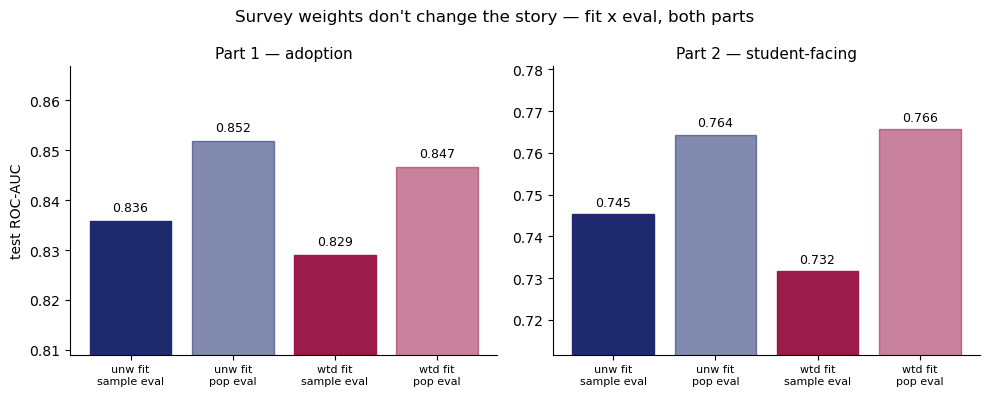

In [ ]:
# ============================================================
# E5b — the 2x2 as a table + grouped-bar figure
# Reuses the pipes/predictions logic; returns numbers instead of printing.
# ============================================================
NAVY, MAROON, GRAY = '#1E2A6D', '#9B1B4A', '#8A8A8A'

def weighted_2x2_vals(tr, te, feats):
    w_tr = w_all.reindex(tr.index).fillna(w_all.median()).values
    w_te = w_all.reindex(te.index).fillna(w_all.median()).values
    pu = make_pipe(feats, HEADLINE_CLF()).fit(tr[feats], tr['y']).predict_proba(te[feats])[:, 1]
    pw = make_pipe(feats, HEADLINE_CLF()).fit(tr[feats], tr['y'],
                clf__sample_weight=w_tr).predict_proba(te[feats])[:, 1]
    return {('unweighted fit', 'sample eval'):     roc_auc_score(te['y'], pu),
            ('unweighted fit', 'population eval'): roc_auc_score(te['y'], pu, sample_weight=w_te),
            ('weighted fit',   'sample eval'):     roc_auc_score(te['y'], pw),
            ('weighted fit',   'population eval'): roc_auc_score(te['y'], pw, sample_weight=w_te)}

res = {'Part 1 — adoption':       weighted_2x2_vals(train,  test,  feature_cols),
       'Part 2 — student-facing': weighted_2x2_vals(train2, test2, feature_cols)}

# ---- table ----
tbl = pd.DataFrame({p: v for p, v in res.items()}).round(3)
tbl.index = pd.MultiIndex.from_tuples(tbl.index, names=['training', 'evaluation'])
display(tbl)
tbl.to_csv(DATA_DIR / "output" / "weighted_auc_2x2.csv")

# ---- grouped bars: 4 combos side by side, one panel per part ----
combos = [('unweighted fit', 'sample eval'), ('unweighted fit', 'population eval'),
          ('weighted fit', 'sample eval'),   ('weighted fit', 'population eval')]
labels = ['unw fit\nsample eval', 'unw fit\npop eval', 'wtd fit\nsample eval', 'wtd fit\npop eval']
colors = [NAVY, NAVY, MAROON, MAROON]
alphas = [1.0, 0.55, 1.0, 0.55]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for ax, (part, vals) in zip(axes, res.items()):
    heights = [vals[c] for c in combos]
    bars = ax.bar(range(4), heights)
    for b, c, a in zip(bars, colors, alphas):
        b.set_color(c); b.set_alpha(a)
    for x, h in enumerate(heights):
        ax.text(x, h + 0.002, f"{h:.3f}", ha='center', fontsize=9)
    ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(min(heights) - 0.02, max(heights) + 0.015)
    ax.set_title(part, fontsize=11)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("test ROC-AUC")
fig.suptitle("Survey weights don't change the story — fit x eval, both parts", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "output" / "weighted_auc_2x2.png", dpi=150, bbox_inches='tight')
plt.show()

<a id="e6"></a>
## E6 · Hyperparameter tuning — SLOW, run last or skip

**Result (this run):** tuned 0.839 vs default 0.836 — **+0.003** therefore we kept defaults kept since the gain is negligible & default settings reduce the risk of overfitting
the split.

In [14]:
# ============================================================
# E6 — hyperparameter tuning (SLOW: 12 candidates x 3 folds — run last or skip)
# v1 receipt: tuned 0.849 vs untuned 0.846 -> kept defaults
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold

param_dist = {
    'clf__n_estimators':  [100, 200, 300],
    'clf__learning_rate': [0.03, 0.05, 0.1],
    'clf__max_depth':     [2, 3, 4],
    'clf__subsample':     [0.8, 1.0],
}
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(make_pipe(feature_cols, HEADLINE_CLF()), param_dist, n_iter=12,
                            cv=cv, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)
search.fit(train[feature_cols], train['y'], groups=train['IDSCHOOL'])
print("best params:", search.best_params_)
print(f"best CV AUC: {search.best_score_:.3f}")
auc_t = roc_auc_score(test['y'], search.best_estimator_.predict_proba(test[feature_cols])[:, 1])
auc_d = roc_auc_score(test['y'],
    make_pipe(feature_cols, HEADLINE_CLF()).fit(train[feature_cols], train['y'])
        .predict_proba(test[feature_cols])[:, 1])
print(f"tuned test AUC {auc_t:.3f} | default test AUC {auc_d:.3f} | gain {auc_t-auc_d:+.3f}")

best params: {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.1}
best CV AUC: 0.834
tuned test AUC 0.839 | default test AUC 0.836 | gain +0.003
